# Water Potability Prediction using Machine Learning

## **1. Introduction**

Access to safe drinking water is an important global issue.

Water quality depends on chemical properties such as **pH**, **hardness**, **sulfate**, and **turbidity**.

## **Target Variable**

- **Potability = 1** → Water is safe to drink  
- **Potability = 0** → Water is not safe to drink

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
df=pd.read_csv("water_potability.csv")
df

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability,Unnamed: 10
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0,NaN
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0,NaN
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0,NaN
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0,NaN
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1,NaN
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1,NaN
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1,NaN
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1,NaN


In [53]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability,Unnamed: 10
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0,NaN
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0,NaN
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0,NaN
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0,NaN
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0,NaN


In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
 10  Unnamed: 10      0 non-null      float64
dtypes: float64(10), int64(1)
memory usage: 281.7 KB


In [55]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability,Unnamed: 10
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000,0.0
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110,NaN
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849,NaN
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000,NaN
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000,NaN
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000,NaN
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000,NaN
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000,NaN


In [56]:
df.isnull().sum()

ph                  491
Hardness              0
Solids                0
Chloramines           0
Sulfate             781
Conductivity          0
Organic_carbon        0
Trihalomethanes     162
Turbidity             0
Potability            0
Unnamed: 10        3276
dtype: int64

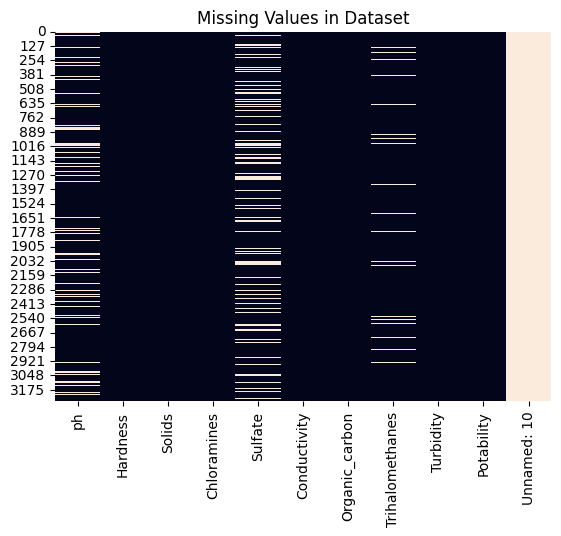

In [57]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values in Dataset")
plt.show()

In [58]:
df["Potability"].value_counts()

Potability
0    1998
1    1278
Name: count, dtype: int64

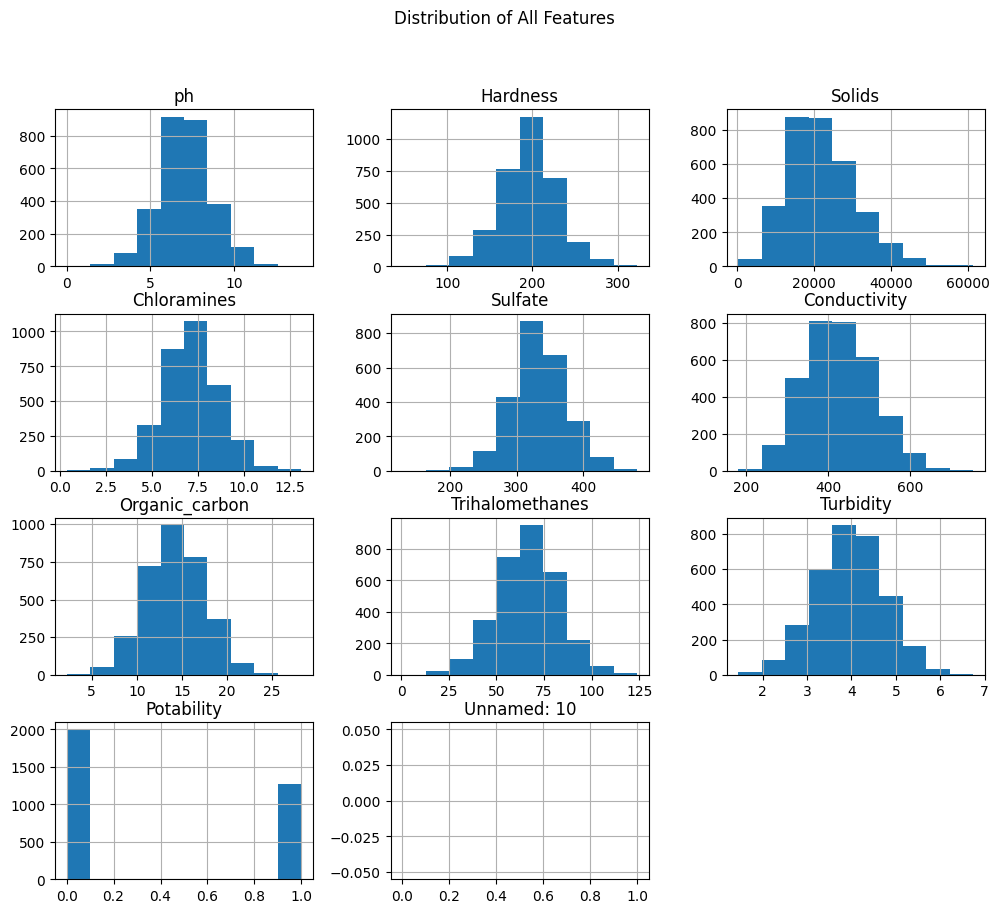

In [59]:
df.hist(figsize=(12,10))
plt.suptitle("Distribution of All Features")
plt.show()

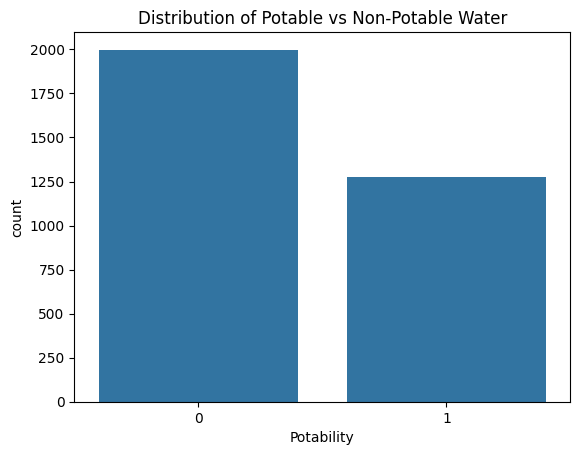

In [60]:
sns.countplot(x="Potability", data=df)
plt.title("Distribution of Potable vs Non-Potable Water")
plt.show()

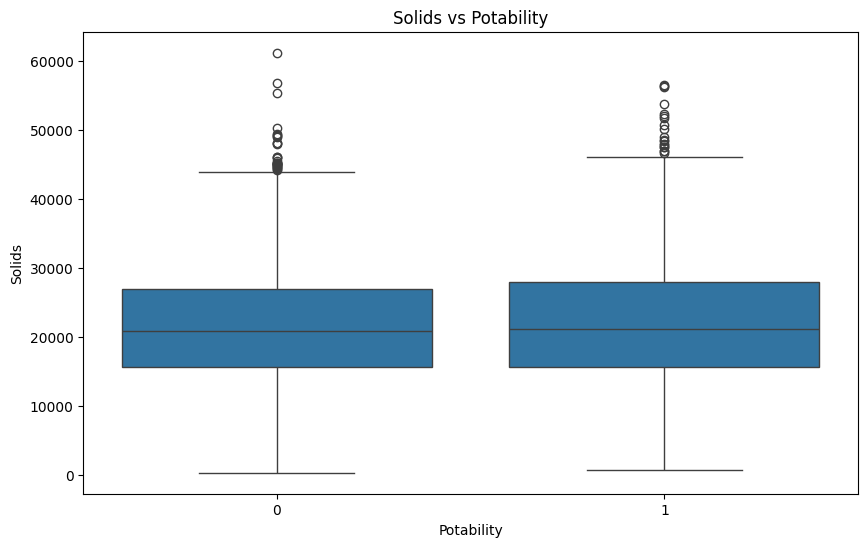

In [61]:
plt.figure(figsize=(10,6))
sns.boxplot(x="Potability", y="Solids", data=df)
plt.title("Solids vs Potability")
plt.show()

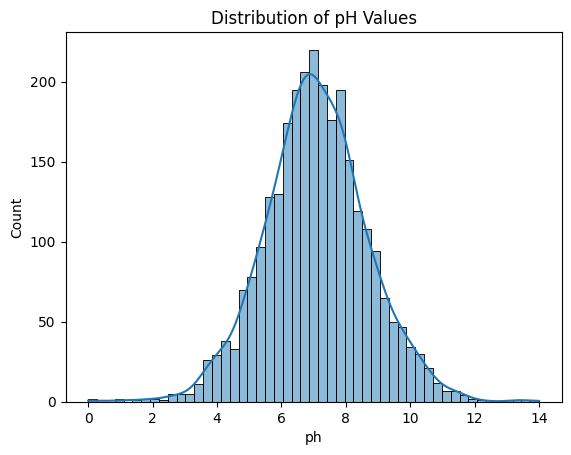

In [62]:
sns.histplot(df["ph"], kde=True)
plt.title("Distribution of pH Values")
plt.show()

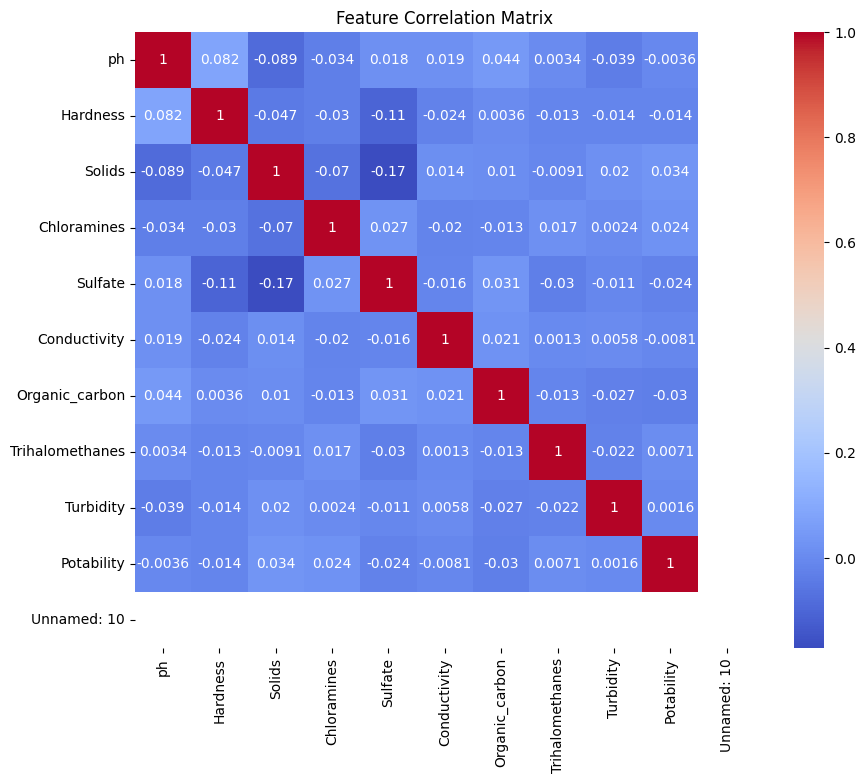

In [63]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

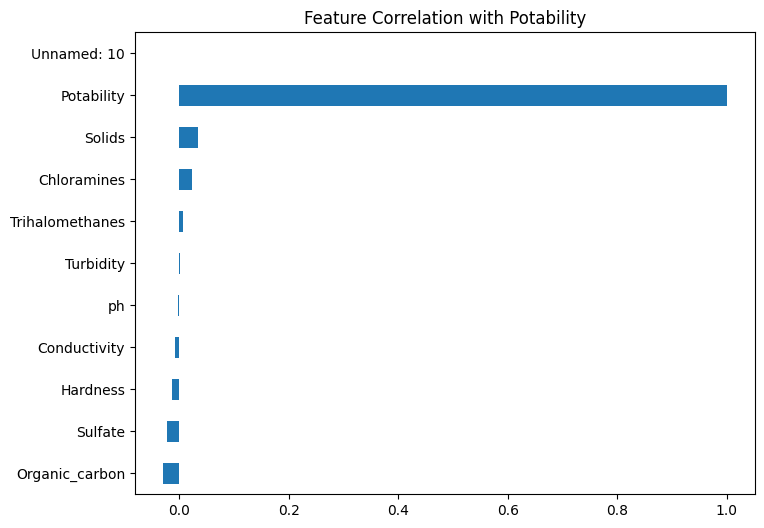

In [64]:
corr = df.corr()["Potability"].sort_values()

corr.plot(kind="barh", figsize=(8,6))
plt.title("Feature Correlation with Potability")
plt.show()

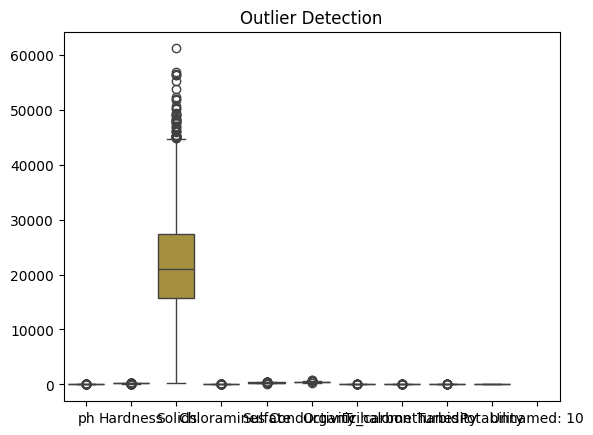

In [65]:
sns.boxplot(data=df)
plt.title("Outlier Detection")
plt.show()

## **2. Key Insights from EDA**

- **The dataset contains several missing values in features such as pH and Sulfate.**

- **The target variable is moderately imbalanced.**

- **Some features such as Solids and Hardness show wider distributions.**

- **Correlation between features is generally low, indicating low multicollinearity.**

## **3. Data Preprocessing**

Data preprocessing is an **essential step in the machine learning pipeline**. Raw data often contains **missing values**, **inconsistent formats**, or features that need to be **scaled** before training a model.

The goal of preprocessing is to **clean and transform the dataset** into a suitable format for machine learning algorithms.

### **Steps Included in This Project**

- **Handling missing values**
- **Separating features and target variable**
- **Splitting the dataset into training and testing sets**
- **Feature scaling**

In [67]:
df.fillna(df.mean(), inplace=True)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability,Unnamed: 10
0,7.080795,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0,NaN
1,3.716080,129.422921,18630.057858,6.635246,333.775777,592.885359,15.180013,56.329076,4.500656,0,NaN
2,8.099124,224.236259,19909.541732,9.275884,333.775777,418.606213,16.868637,66.420093,3.055934,0,NaN
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0,NaN
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1,NaN
3272,7.808856,193.553212,17329.802160,8.061362,333.775777,392.449580,19.903225,66.396293,2.798243,1,NaN
3273,9.419510,175.762646,33155.578218,7.350233,333.775777,432.044783,11.039070,69.845400,3.298875,1,NaN
3274,5.126763,230.603758,11983.869376,6.303357,333.775777,402.883113,11.168946,77.488213,4.708658,1,NaN


In [68]:
X = df.drop("Potability", axis=1)
y = df["Potability"]

In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [70]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/extmath.py:1207: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/extmath.py:1212: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/extmath.py:1236: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


## **4. Final Prepared Dataset**

After preprocessing, the dataset is **ready for machine learning**.

- **Missing values have been handled**
- **Features and target variables have been separated**
- **Data has been split into training and testing sets**
- **Feature scaling has been applied**

The processed dataset can now be used to train **classification models** such as **Logistic Regression**, **Random Forest**, or **Gradient Boosting**.